# Расчетно-графическое задание по теме «Многомерные распределения»
Расчетно-графическое задание выполняется в Jupyter Notebook (Python 3.14). \
Выполнил: Новиков Алексей Георгиевич M3233

## Блок 1
### Задание 1
> Каждому из вас привязан отдельный вариант задания. Номер варианта равняется Вашему
> номеру в таблице. В соответствующем файле находится таблица с законом многомерного
> дискретного распределения. Откройте и перенесите ее в удобную для Вас среду.

Считываем таблицу в `pandas DataFrame`, а вероятности сохраняем в массив `p_array` для дальнейших вычислений:

In [215]:
import numpy as np
import pandas as pd

p_data = pd.read_csv(filepath_or_buffer="Вариант 17.csv")
probability_data = p_data.drop(columns='XY')
saved_columns = np.array(probability_data.columns)
saved_index = p_data['XY'].to_numpy()
x_values = saved_index.astype(float)
y_values = saved_columns.astype(float)

p_array = np.array(probability_data)

print(p_data.to_string(index=False))

 XY    -76    -17    -14     19     30     31     45     46     60     79
-99 0.0066 0.0090 0.0062 0.0003 0.0024 0.0354 0.0038 0.0047 0.0047 0.0090
-74 0.0066 0.0025 0.0094 0.0064 0.0393 0.0120 0.0059 0.0303 0.0081 0.0023
-66 0.0030 0.0015 0.0156 0.0042 0.0031 0.0020 0.0090 0.0183 0.0178 0.0038
-27 0.0081 0.0015 0.0074 0.0066 0.0007 0.0034 0.0065 0.0023 0.0053 0.0100
 42 0.0017 0.0206 0.0053 0.0008 0.0039 0.0175 0.0181 0.0104 0.0051 0.0033
 77 0.0250 0.0123 0.0004 0.0094 0.0253 0.0211 0.0203 0.0040 0.0245 0.0104
 78 0.0020 0.0044 0.0001 0.0056 0.0041 0.0151 0.0062 0.0007 0.0006 0.0065
 83 0.0104 0.0025 0.0110 0.0458 0.0002 0.0221 0.0197 0.0261 0.0046 0.0058
 86 0.0082 0.0330 0.0069 0.0018 0.0195 0.0137 0.0108 0.0150 0.0157 0.0073
 89 0.0060 0.0169 0.0081 0.0059 0.0068 0.0109 0.0088 0.0061 0.0061    NaN


### Задание 2
> Одно из значений вероятности закона распределения не указано. Найдите его. Чем Вы
> воспользовались, чтобы найти это значение?

Найдём неизвестную вероятность по условию нормировки:
$$\sum_i \sum_j p_{ij} = 1$$

In [216]:
p_sum = np.nansum(p_array)
unknow_num = round(1 - p_sum, 10)
p_array[np.isnan(p_array)] = unknow_num
print(unknow_num)

0.0246


### Задание 3
> Найдите многомерную функцию распределения для заданного закона.

Многомерная функция распределения считается накоплением вероятностей:
$$F(x_i, y_j) = P(X \le x_i, Y \le y_j) = \sum_{k \le i} \sum_{l \le j} p_{kl}$$

Для таблицы используем рекуррентные формулы:
`F[0][0] = p[0][0]`  
`F[i][0] = F[i - 1][0] + p[i][0]` для `i > 0`  
`F[0][j] = F[0][j - 1] + p[0][j]` для `j > 0`  
`F[i][j] = F[i - 1][j] + F[i][j - 1] - F[i - 1][j - 1] + p[i][j]` для `i > 0`, `j > 0`

Реализуем это в коде:


In [217]:
F = np.zeros_like(p_array)
for i in range(p_array.shape[0]):
    for j in range(p_array.shape[1]):
        if i == 0 and j == 0:
            F[i][j] = p_array[i][j]
        elif j == 0:
            F[i][j] = F[i - 1][j] + p_array[i][j]
        elif i == 0:
            F[i][j] = F[i][j - 1] + p_array[i][j]
        else:
            F[i][j] = F[i - 1][j] + F[i][j - 1] - F[i - 1][j - 1] + p_array[i][j]

F_data = pd.DataFrame(F, columns=saved_columns, index=saved_index)

print(F_data.to_string())

        -76     -17     -14      19      30      31      45      46      60      79
-99  0.0066  0.0156  0.0218  0.0221  0.0245  0.0599  0.0637  0.0684  0.0731  0.0821
-74  0.0132  0.0247  0.0403  0.0470  0.0887  0.1361  0.1458  0.1808  0.1936  0.2049
-66  0.0162  0.0292  0.0604  0.0713  0.1161  0.1655  0.1842  0.2375  0.2681  0.2832
-27  0.0243  0.0388  0.0774  0.0949  0.1404  0.1932  0.2184  0.2740  0.3099  0.3350
 42  0.0260  0.0611  0.1050  0.1233  0.1727  0.2430  0.2863  0.3523  0.3933  0.4217
 77  0.0510  0.0984  0.1427  0.1704  0.2451  0.3365  0.4001  0.4701  0.5356  0.5744
 78  0.0530  0.1048  0.1492  0.1825  0.2613  0.3678  0.4376  0.5083  0.5744  0.6197
 83  0.0634  0.1177  0.1731  0.2522  0.3312  0.4598  0.5493  0.6461  0.7168  0.7679
 86  0.0716  0.1589  0.2212  0.3021  0.4006  0.5429  0.6432  0.7550  0.8414  0.8998
 89  0.0776  0.1818  0.2522  0.3390  0.4443  0.5975  0.7066  0.8245  0.9170  1.0000


### Задание 4.1
> Найдите законы и функции маргинальных распределений для каждой координаты
> заданного случайного вектора.

Маргинальные вероятности для $X$ и $Y$ считаются суммированием строк и столбцов:
$$p_i = P(X = x_i) = \sum_{j=1}^{m} p_{ij}$$
$$q_j = P(Y = y_j) = \sum_{i=1}^{n} p_{ij}$$

Функции маргинальных распределений берём из таблицы $F$:
$$F_X(x_i) = F(x_i, +\infty)$$
$$F_Y(y_j) = F(+\infty, y_j)$$


In [218]:
p_i = p_array.sum(axis=1)
p_j = p_array.sum(axis=0)

F_x = F[:, -1]
F_y = F[-1, :]
print(f'p_i: {p_i}\np_j: {p_j}\n'
      f'F_x: {F_x}\nF_y: {F_y}')

p_i: [0.0821 0.1228 0.0783 0.0518 0.0867 0.1527 0.0453 0.1482 0.1319 0.1002]
p_j: [0.0776 0.1042 0.0704 0.0868 0.1053 0.1532 0.1091 0.1179 0.0925 0.083 ]
F_x: [0.0821 0.2049 0.2832 0.335  0.4217 0.5744 0.6197 0.7679 0.8998 1.    ]
F_y: [0.0776 0.1818 0.2522 0.339  0.4443 0.5975 0.7066 0.8245 0.917  1.    ]


### Задание 4.2
> Постройте гистограммы для законов маргинальных распределений, где по оси абсцисс будут
принимаемые случайными величинами значения, а по оси ординат - вероятности их
появления.

Для $X$ строим столбцы с высотами $p_i$, для $Y$ - столбцы с высотами $q_j$.

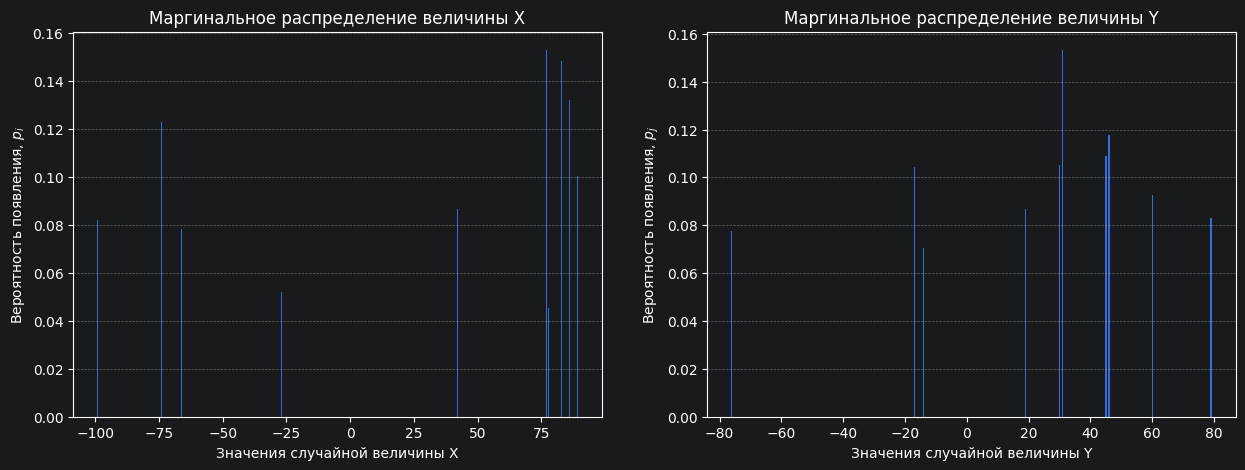

In [219]:
import matplotlib.pyplot as plt

fig, (gist1, gist2) = plt.subplots(1, 2, figsize=(15, 5))
bar_width = 0.4

gist1.bar(x_values, p_i, width=bar_width)
gist1.set_title('Маргинальное распределение величины X')
gist1.set_xlabel('Значения случайной величины X')
gist1.set_ylabel('Вероятность появления, $p_i$')
gist1.grid(axis='y', linestyle='--')

gist2.bar(y_values, p_j, width=bar_width)
gist2.set_title('Маргинальное распределение величины Y')
gist2.set_xlabel('Значения случайной величины Y')
gist2.set_ylabel('Вероятность появления, $p_j$')
gist2.grid(axis='y', linestyle='--')

plt.show()

### Задание 4.3
> Постройте графики функций распределения.

Для дискретных случайных величин функции распределения строим ступенчатыми графиками по значениям $F_X$ и $F_Y$.

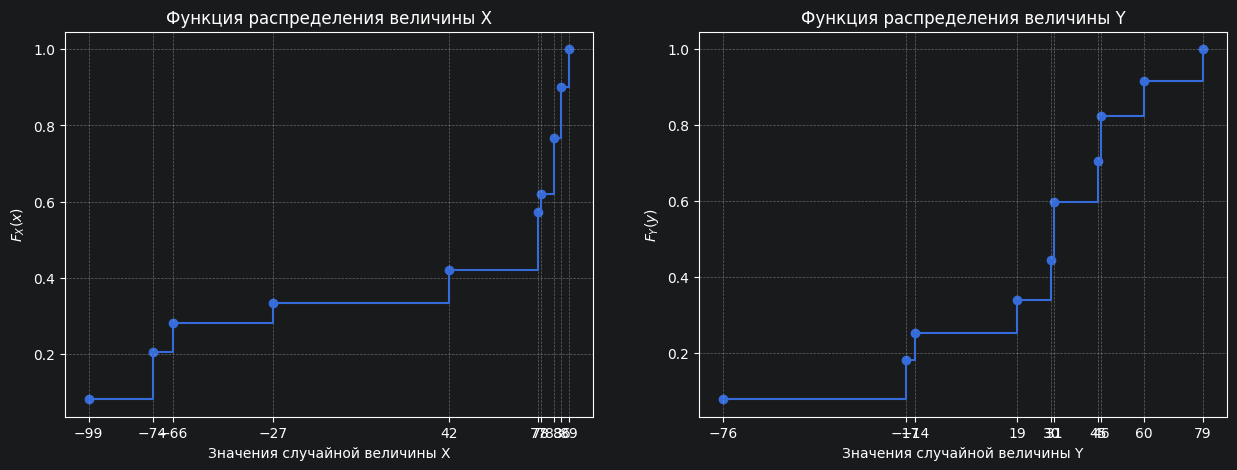

In [220]:
fig, (graph1, graph2) = plt.subplots(1, 2, figsize=(15, 5))

graph1.step(x_values, F_x, where='post')
graph1.scatter(x_values, F_x)
graph1.set_xticks(x_values)
graph1.set_title('Функция распределения величины X')
graph1.set_xlabel('Значения случайной величины X')
graph1.set_ylabel('$F_X(x)$')
graph1.grid(axis='both', linestyle='--')

graph2.step(y_values, F_y, where='post')
graph2.scatter(y_values, F_y)
graph2.set_xticks(y_values)
graph2.set_title('Функция распределения величины Y')
graph2.set_xlabel('Значения случайной величины Y')
graph2.set_ylabel('$F_Y(y)$')
graph2.grid(axis='both', linestyle='--')

plt.show()

### Задание 5
> Для маргинальных распределений найдите числовые характеристики:
> - математическое ожидание;
> - дисперсию;
> - среднее квадратичное отклонение;
> - медиану;
> - моду.

Для дискретной случайной величины $X$ с законом распределения $P(X = x_i) = p_i$ используем формулы:
$$E(X) = \sum_i x_i p_i$$
$$D(X) = E(X^2) - (E(X))^2 = \sum_i x_i^2 p_i - (E(X))^2$$
$$\sigma_X = \sqrt{D(X)}$$
$$Me = \min\{x_i: F(x_i) \ge 0,5\}$$
$$Mo = x_k, \quad p_k = \max_i p_i$$

В сборнике формула $F(Me) = 0,5$ приведена для непрерывного распределения. Для дискретного распределения функция $F$ ступенчатая, поэтому значение $F(x_i) = 0,5$ может не встретиться. В этом случае берём первое значение, в котором $F(x_i)$ становится не меньше $0,5$.

Для случайной величины $Y$ характеристики считаются по тем же формулам, но с вероятностями $q_j$.

In [221]:
def characteristic(values, probs):
    mean = np.sum(values * probs)
    variance = np.sum(values ** 2 * probs) - mean ** 2
    std = np.sqrt(variance)
    probability_sum = 0
    median = values[-1]
    for i in range(len(probs)):
        probability_sum += probs[i]
        if probability_sum >= 0.5:
            median = values[i]
            break
    mode = values[0]
    max_probability = probs[0]
    for i in range(1, len(probs)):
        if probs[i] > max_probability:
            max_probability = probs[i]
            mode = values[i]

    return mean, variance, std, median, mode


characteristics = pd.DataFrame(
    [
        characteristic(x_values, p_i),
        characteristic(y_values, p_j),
    ],
    index=['X', 'Y'],
    columns=[
        'Математическое ожидание',
        'Дисперсия',
        'Среднее квадратичное отклонение',
        'Медиана',
        'Мода',
    ]
)

mean_x = characteristics.loc['X', 'Математическое ожидание']
mean_y = characteristics.loc['Y', 'Математическое ожидание']
variance_x = characteristics.loc['X', 'Дисперсия']
variance_y = characteristics.loc['Y', 'Дисперсия']

print(characteristics.to_string())

   Математическое ожидание    Дисперсия  Среднее квадратичное отклонение  Медиана  Мода
X                  27.7130  5212.010231                        72.194253     77.0  77.0
Y                  23.3427  1541.985057                        39.268118     31.0  31.0


### Задание 6
> Проверьте независимость искомых случайных величин.

Случайные величины $X$ и $Y$ независимы тогда и только тогда, когда для любых $i, j$ выполняется равенство:
$$P(X = x_i, Y = y_j) = P(X = x_i)P(Y = y_j)$$
$$p_{ij} = p_i q_j$$

Проверим это условие для всех значений таблицы. Если хотя бы для одной пары значений равенство не выполняется, случайные величины зависимы.

In [222]:
max_difference = 0
is_independent = True
eps = 10 ** -10

for i in range(p_array.shape[0]):
    for j in range(p_array.shape[1]):
        expected_probability = p_i[i] * p_j[j]
        difference = abs(p_array[i][j] - expected_probability)

        if difference > max_difference:
            max_difference = difference
        if difference > eps:
            is_independent = False

print(f'Максимальное отличие p_ij от p_i * p_j: {max_difference:.8f}')

if is_independent:
    print('Случайные величины X и Y независимы.')
else:
    print('Случайные величины X и Y зависимы.')

Максимальное отличие p_ij от p_i * p_j: 0.03293624
Случайные величины X и Y зависимы.


### Задание 7
> Посчитайте коэффициент линейной корреляции данных величин. Равен ли он нулю? Есть ли тому причина? Что еще Вы можете сказать, глядя на него?

Коэффициент линейной корреляции вычисляется по формуле:
$$cov(X, Y) = E((X - E(X))(Y - E(Y))) = E(XY) - E(X)E(Y)$$
$$E(XY) = \sum_i \sum_j x_i y_j p_{ij}$$
$$r_{XY} = \frac{cov(X, Y)}{\sigma_X \sigma_Y} = \frac{E(XY) - E(X)E(Y)}{\sqrt{D(X)D(Y)}}$$

In [223]:
mean_xy = 0
for i in range(len(x_values)):
    for j in range(len(y_values)):
        mean_xy += x_values[i] * y_values[j] * p_array[i][j]

cov_xy = mean_xy - mean_x * mean_y
r_xy = cov_xy / np.sqrt(variance_x * variance_y)

if abs(r_xy) < eps:
    zero_result = 'да'
else:
    zero_result = 'нет'

correlation_data = pd.DataFrame(
    {
        'r_xy': [r_xy],
        'Равен нулю': [zero_result],
    }
)

print(correlation_data.to_string(index=False))

     r_xy Равен нулю
-0.038166        нет


По вычислениям получаем $r_{XY} \approx -0.038166$.

Коэффициент не равен нулю, но по модулю очень мал. Это значит, что линейная связь между $X$ и $Y$ практически отсутствует.

При этом из задания 6 случайные величины $X$ и $Y$ зависимы. Противоречия нет, так как коэффициент корреляции показывает только линейную зависимость, поэтому зависимые случайные величины могут иметь почти нулевую корреляцию.

### Задание 8
> Постройте уравнение регрессии $Y$ на $X$: $E(Y \mid X = x)$.

Для дискретного распределения условное математическое ожидание $Y$ при фиксированном значении $X = x_i$ вычисляется так:
$$E(Y \mid X = x_i) = \sum_j y_j P(Y = y_j \mid X = x_i)$$
$$P(Y = y_j \mid X = x_i) = \frac{p_{ij}}{p_i}$$
$$E(Y \mid X = x_i) = \frac{\sum_j y_j p_{ij}}{p_i}$$

Уравнение регрессии зададим таблицей значений $E(Y \mid X = x_i)$ для всех значений $x_i$.

    x  E(Y | X = x)
-99.0     22.093788
-74.0     27.067590
-66.0     30.369093
-27.0     19.563707
 42.0     22.845444
 77.0     18.769483
 78.0     29.359823
 83.0     22.912955
 86.0     18.633813
 89.0     27.777445


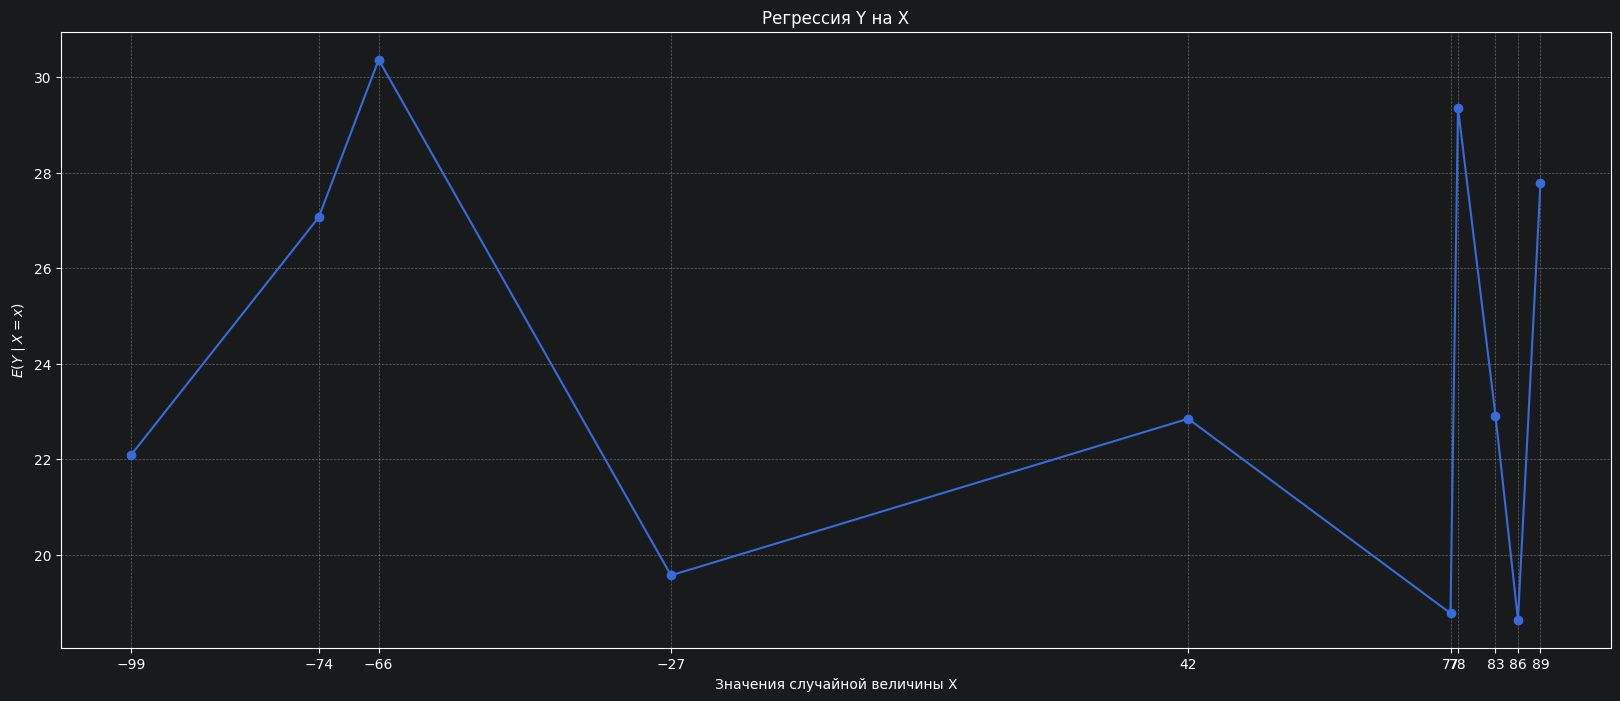

In [224]:
regression_y_on_x = np.zeros_like(x_values)
for i in range(len(x_values)):
    conditional_mean = 0
    for j in range(len(y_values)):
        conditional_mean += y_values[j] * p_array[i][j]
    regression_y_on_x[i] = conditional_mean / p_i[i]

regression_data = pd.DataFrame(
    {
        'x': x_values,
        'E(Y | X = x)': regression_y_on_x,
    }
)

print(regression_data.to_string(index=False))

plt.figure(figsize=(20, 8))
plt.plot(x_values, regression_y_on_x, marker='o')
plt.xticks(x_values)
plt.title('Регрессия Y на X')
plt.xlabel('Значения случайной величины X')
plt.ylabel(r'$E(Y \mid X = x)$')
plt.grid(axis='both', linestyle='--')
plt.show()

## Блок 2
### Задание 1
> Выберите одно из маргинальных распределений ($X$ или $Y$) и смоделируйте данные из этого распределения. Возьмите не менее 10000 значений.

Выберем маргинальное распределение случайной величины $X$ и смоделируем:

In [225]:
import random

x_distribution = np.zeros_like(p_i)
probability_sum = 0
for i in range(len(p_i)):
    probability_sum += p_i[i]
    x_distribution[i] = probability_sum
x_distribution[-1] = 1.0


def generate_discrete_value(values, cumulative_distribution):
    random_value = random.random()
    for i in range(len(cumulative_distribution)):
        if random_value <= cumulative_distribution[i]:
            return values[i]
    return values[-1]


sample_count = 100000
generated_x = np.zeros(sample_count)
generated_counts = np.zeros_like(x_values)

for i in range(sample_count):
    generated_value = generate_discrete_value(x_values, x_distribution)
    generated_x[i] = generated_value

    for j in range(len(x_values)):
        if generated_value == x_values[j]:
            generated_counts[j] += 1
            break

print(f'Количество сгенерированных значений: {sample_count}')
print(generated_x[:200])

Количество сгенерированных значений: 100000
[ 89.  89.  77.  89.  77.  86.  77.  77. -74.  86.  86.  89.  77.  77.
 -99.  89. -99.  86. -99.  77.  77.  89. -27.  42.  86. -66.  77.  89.
 -66.  77.  77. -66.  42.  89. -74. -74.  83.  42. -27. -99. -99. -99.
  86.  77. -66.  83.  83.  77. -99.  77.  83.  77.  77.  42. -99.  42.
 -74.  83.  83.  77. -66. -27.  42.  83. -99.  89.  77. -66.  89. -66.
  78. -74.  86.  83. -27.  42.  89. -74.  77.  77. -74.  83.  42. -99.
  77.  83.  83.  86.  42.  77.  77.  77. -66.  86. -99. -66.  83. -27.
  77.  78.  86.  78.  83.  77.  86. -74. -99.  86.  77. -74.  86. -74.
  89.  83.  89.  89.  86.  42.  83.  78. -74. -99. -27.  42.  83.  86.
  77. -66.  83. -66.  86. -74.  89.  89.  77.  77.  77.  89. -74.  83.
  89. -99. -74.  86.  77.  89. -27.  86.  42.  83.  77. -27.  86.  86.
 -99.  86. -27. -99. -66. -74.  86.  86. -99. -66.  78. -74.  86.  42.
  77.  83. -74.  89.  89.  89. -66. -99.  42.  83.  83.  89.  89.  83.
  83.  77.  77.  83. -27. -99. -9

### Задание 2
> Составьте таблицу, где Вы для каждого значения случайной величины посчитаете относительную частоту ее появления в сгенерированных данных. Постройте по этой таблице гистограмму, аналогичную заданию 1.4.

Относительная частота значения $x_i$ вычисляется по формуле:
$$\nu_i = \frac{n_i}{n},$$
где $n_i$ - количество появлений значения $x_i$, а $n$ - общий размер смоделированной выборки.

Посчитаем в коде и построим таблицу и гистограмму, сравним её с 1.4 гистограммой:

 Значение X  Теоретическая вероятность  Количество появлений  Относительная частота  Отклонение
      -99.0                     0.0821                8189.0                0.08189     0.00021
      -74.0                     0.1228               12283.0                0.12283     0.00003
      -66.0                     0.0783                7817.0                0.07817     0.00013
      -27.0                     0.0518                5168.0                0.05168     0.00012
       42.0                     0.0867                8726.0                0.08726     0.00056
       77.0                     0.1527               15387.0                0.15387     0.00117
       78.0                     0.0453                4402.0                0.04402     0.00128
       83.0                     0.1482               15016.0                0.15016     0.00196
       86.0                     0.1319               13280.0                0.13280     0.00090
       89.0                     0.1002  

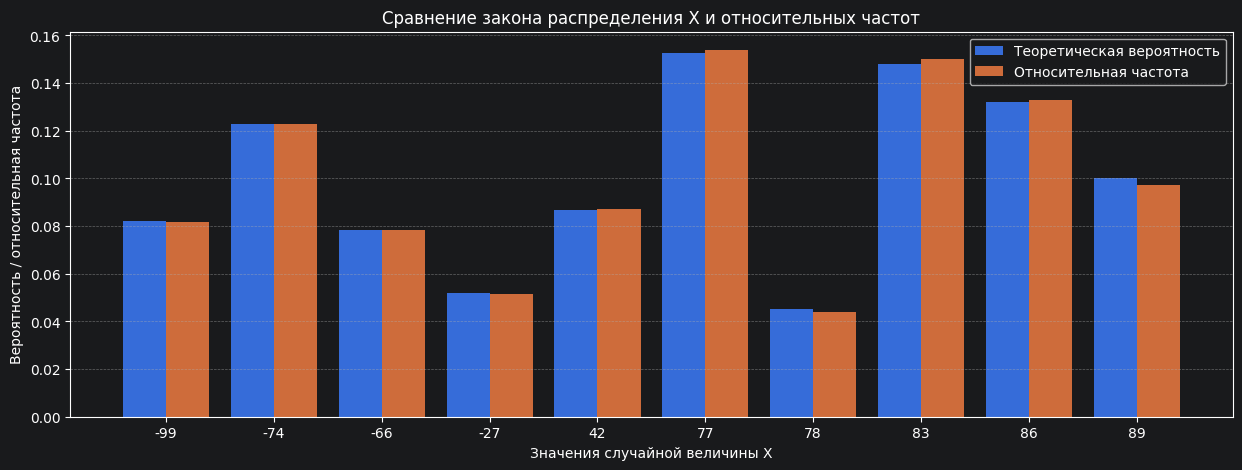

In [226]:
relative_frequencies = generated_counts / sample_count

frequency_difference = np.zeros_like(x_values)
for i in range(len(x_values)):
    frequency_difference[i] = abs(p_i[i] - relative_frequencies[i])

frequency_data = pd.DataFrame(
    {
        'Значение X': x_values,
        'Теоретическая вероятность': p_i,
        'Количество появлений': generated_counts,
        'Относительная частота': relative_frequencies,
        'Отклонение': frequency_difference,
    }
)

print(frequency_data.to_string(index=False))

x_positions = np.arange(len(x_values))
x_labels = []
for value in x_values:
    x_labels.append(str(int(value)))

plt.figure(figsize=(15, 5))
plt.bar(x_positions - bar_width / 2, p_i, width=bar_width, label='Теоретическая вероятность')
plt.bar(x_positions + bar_width / 2, relative_frequencies, width=bar_width, label='Относительная частота')
plt.xticks(x_positions, x_labels)
plt.title('Сравнение закона распределения X и относительных частот')
plt.xlabel('Значения случайной величины X')
plt.ylabel('Вероятность / относительная частота')
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.show()

Гистограмма относительных частот почти идентична гистограмме теоретического закона распределения. Это следует из теоремы Бернулли, частного случая закона больших чисел для относительной частоты: при увеличении числа независимых испытаний относительная частота события $X = x_i$ стремится к вероятности $P(X = x_i)$.

### Задание 3
> Возьмите любую конечную возрастающую натуральную последовательность чисел $\{n_i\}_{i=1}^{N}$. Для каждого значения $n_i$ возьмите $n_i$ сгенерированных значений и посчитайте для них среднее арифметическое: $a_i = \frac{S_{n_i}}{n_i}$. Постройте график зависимости $a_i$ от $n_i$.

Для каждого $n_i$ считаем:
$$S_{n_i} = X_1 + X_2 + \ldots + X_{n_i}$$
$$a_i = \frac{S_{n_i}}{n_i}$$

В качестве последовательности возьмём значения от 1000 до 100000 с шагом 1000.

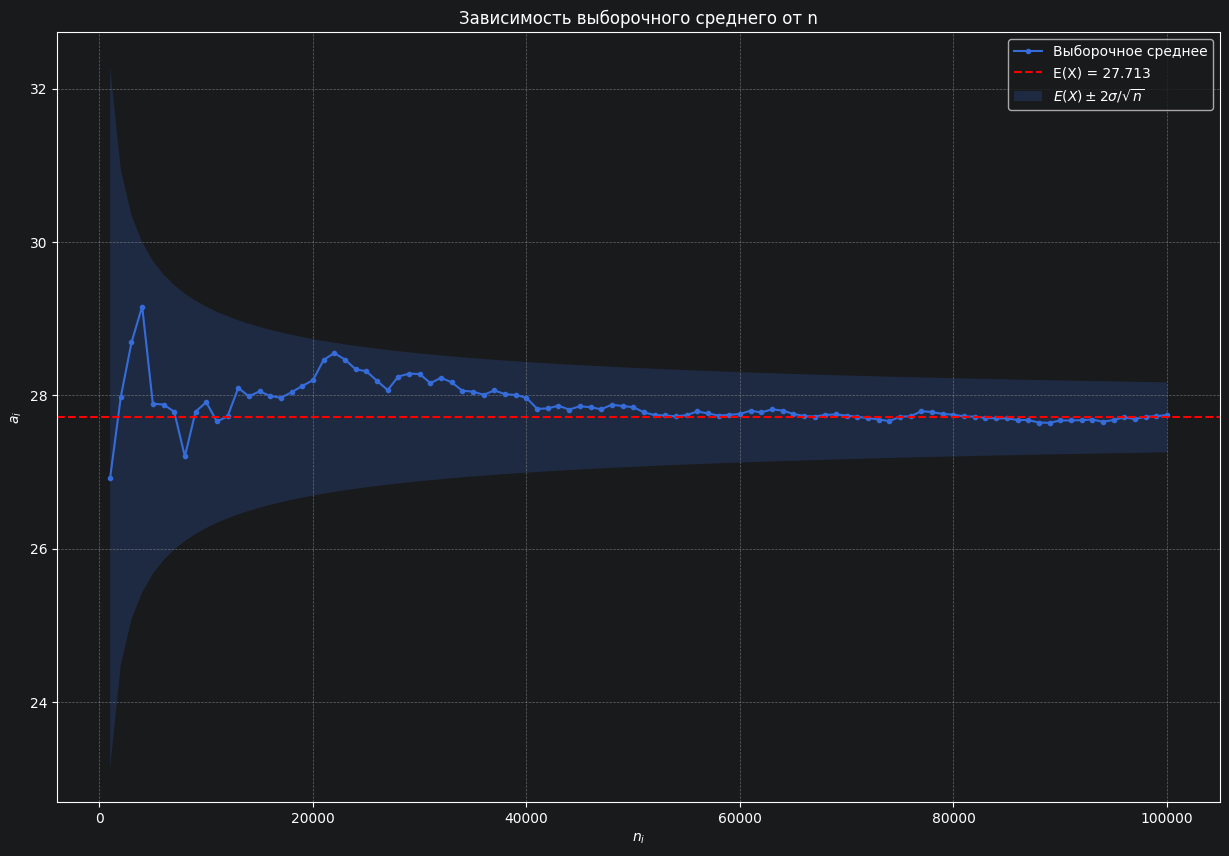

In [227]:
n_values = np.arange(1000, sample_count + 1, 1000)
sums = np.zeros_like(generated_x)
values_sum = 0
for i in range(len(generated_x)):
    values_sum += generated_x[i]
    sums[i] = values_sum
sample_means = np.array([
    sums[n - 1] / n
    for n in n_values
])

plt.figure(figsize=(15, 10))
plt.plot(n_values, sample_means, marker='o', markersize=3, label='Выборочное среднее')
plt.axhline(mean_x, color='red', linestyle='--', label=f'E(X) = {mean_x}')
plt.title('Зависимость выборочного среднего от n')
plt.xlabel('$n_i$')
plt.ylabel('$a_i$')
plt.fill_between(
    n_values,
    mean_x - 2 * np.sqrt(variance_x / n_values),
    mean_x + 2 * np.sqrt(variance_x / n_values),
    alpha=0.2,
    label=r'$E(X) \pm 2\sigma/\sqrt{n}$'
)
plt.grid(axis='both', linestyle='--')
plt.legend()
plt.show()

На графике выборочное среднее $a_i$ при росте $n_i$ постепенно стабилизируется около математического ожидания $E(X)$.

Это объясняется законом больших чисел Хинчина. Если $X_1, X_2, \ldots, X_n$ независимы, одинаково распределены и имеют конечное математическое ожидание $E(X)$, то их среднее арифметическое стремится по вероятности к $E(X)$ при $n \to \infty$.

Небольшие колебания графика даже при $n = 100000$ объясняются достаточно большой дисперсией исходной случайной величины: $D(X) \approx 5212, \sigma_X \approx 72.2.$ Стандартная ошибка равна: $\sigma_{\overline X} = \frac{\sigma_X}{\sqrt{n}}.$ $\sigma_{\overline X} = \frac{72.2}{\sqrt{100000}} \approx 0.228.$

По Центральной предельной теореме выборочное среднее при больших $n$ имеет приближённо нормальное распределение: $\overline X \sim N\left(E(X), \frac{D(X)}{n}\right).$
Для интервала в две стандартные ошибки имеем: $P(|\overline X - E(X)| < 2\sigma_{\overline X}) = 2\Phi(2) \approx 2 \cdot 0.4772 = 0.9544.$
Следовательно, примерно с вероятностью \(95,44\%\) выборочное среднее находится в пределах: $E(X) \pm 2\sigma_{\overline X}.$

Для $n = 100000$ это даёт интервал: $E(X) \pm 2\sigma_{\overline X} \Rightarrow 27.7 \pm 0.456.$ Таким образом, отклонения среднего арифметического от $E(X)$ не противоречат закону больших чисел.